In [1]:
# Analiza/wykresy mapy cykl-do-cyklu (sugestia Homoli, 20260822.txt) - CZYTA
# WYLACZNIE juz zapisane wyniki z results/cycle_scan_*.csv (produkowane
# przez 20260822c.ipynb) - NIE odpala zadnego skanu, bezpiecznie odpalac
# "od gory do dolu" wielokrotnie w miare doplywania nowych wynikow (patrz
# zasada bezpieczenstwa opisana w 20260822c.ipynb komorka 0 / 20260820.txt
# pkt 11).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
HOMOLA_LOG10_PPDF_BENCHMARK = -8

# Rozpoznawanie stacji z nazwy pliku po ZNANEJ liscie (najpierw dluzsze
# nazwy, np. "jung1" przed "jung") - bezpieczniejsze niz czysty regex, bo
# nazwy stacji i etykiety cykli obie uzywaja podkreslen.
STATION_NAMES = sorted(
    ["mosc", "oulu", "athn", "hrms", "sopb", "thul", "lmks", "apty", "jung1",
     "sopo", "fsmt", "jung", "newk", "pwnk", "mxco", "nain", "tera", "invk",
     "aatb", "psnm", "nanm", "mcrl"],
    key=len, reverse=True,
)
FILENAME_RE = re.compile(r"^(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)$")


def parse_result_filename(path):
    base = os.path.basename(path)
    if not (base.startswith("cycle_scan_") and base.endswith(".csv")):
        return None
    rest = base[len("cycle_scan_"):-len(".csv")]
    station = next((s for s in STATION_NAMES if rest.startswith(s + "_")), None)
    if station is None:
        return None
    m = FILENAME_RE.match(rest[len(station) + 1:])
    if not m:
        return None
    return dict(station=station, cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


rows = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_result_filename(path)
    if meta is None:
        continue
    df_scan = pd.read_csv(path, parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df_scan) == 0:
        continue
    best = df_scan.loc[df_scan["PPDF"].idxmin()]
    log10_ppdf = np.log10(best["PPDF"]) if best["PPDF"] > 0 else -np.inf
    rows.append(dict(
        **meta,
        t0_best=best["t0"], Np=int(best["Np"]), Nm=int(best["Nm"]),
        PPDF=best["PPDF"], sigma=best["sigma"], log10_PPDF=log10_ppdf,
        n_valid_candidates=len(df_scan),
        beats_benchmark=(best["PPDF"] > 0 and log10_ppdf < HOMOLA_LOG10_PPDF_BENCHMARK),
    ))

summary = pd.DataFrame(rows)
print(f"Wczytano {len(summary)} ukonczonych zadan (stacja x cykl x P_days x d) z {RESULTS_DIR}")
if len(summary):
    summary["cycle_year"] = summary["cycle"].str.extract(r"cycle_(\d{4})").astype(int)
    summary = summary.sort_values(["P_days", "d", "cycle_year", "station"])
    summary.to_csv(f"{RESULTS_DIR}/cycle_scan_summary.csv", index=False)
    pd.set_option("display.width", 160)
    print(summary[["station", "cycle", "P_days", "d", "t0_best", "log10_PPDF", "beats_benchmark"]].to_string(index=False))
else:
    print("Brak wynikow na dysku jeszcze - odpal (lub dokoncz) 20260822c.ipynb.")


Wczytano 384 ukonczonych zadan (stacja x cykl x P_days x d) z ../results
station                 cycle  P_days  d    t0_best  log10_PPDF  beats_benchmark
   aatb            cycle_1964    1675  1 1971-09-07   -2.203176            False
   hrms            cycle_1964    1675  1 1971-01-09   -5.905033            False
   jung            cycle_1964    1675  1 1974-09-18   -2.349471            False
   mosc            cycle_1964    1675  1 1970-04-13   -2.751918            False
   newk            cycle_1964    1675  1 1970-01-25   -3.748752            False
   oulu            cycle_1964    1675  1 1971-08-21   -3.446753            False
   sopo            cycle_1964    1675  1 1970-03-04   -4.510221            False
   tera            cycle_1964    1675  1 1969-08-29   -3.593397            False
   thul            cycle_1964    1675  1 1970-01-23   -4.363073            False
   aatb            cycle_1976    1675  1 1981-12-27   -8.621868             True
   hrms            cycle_1976    167

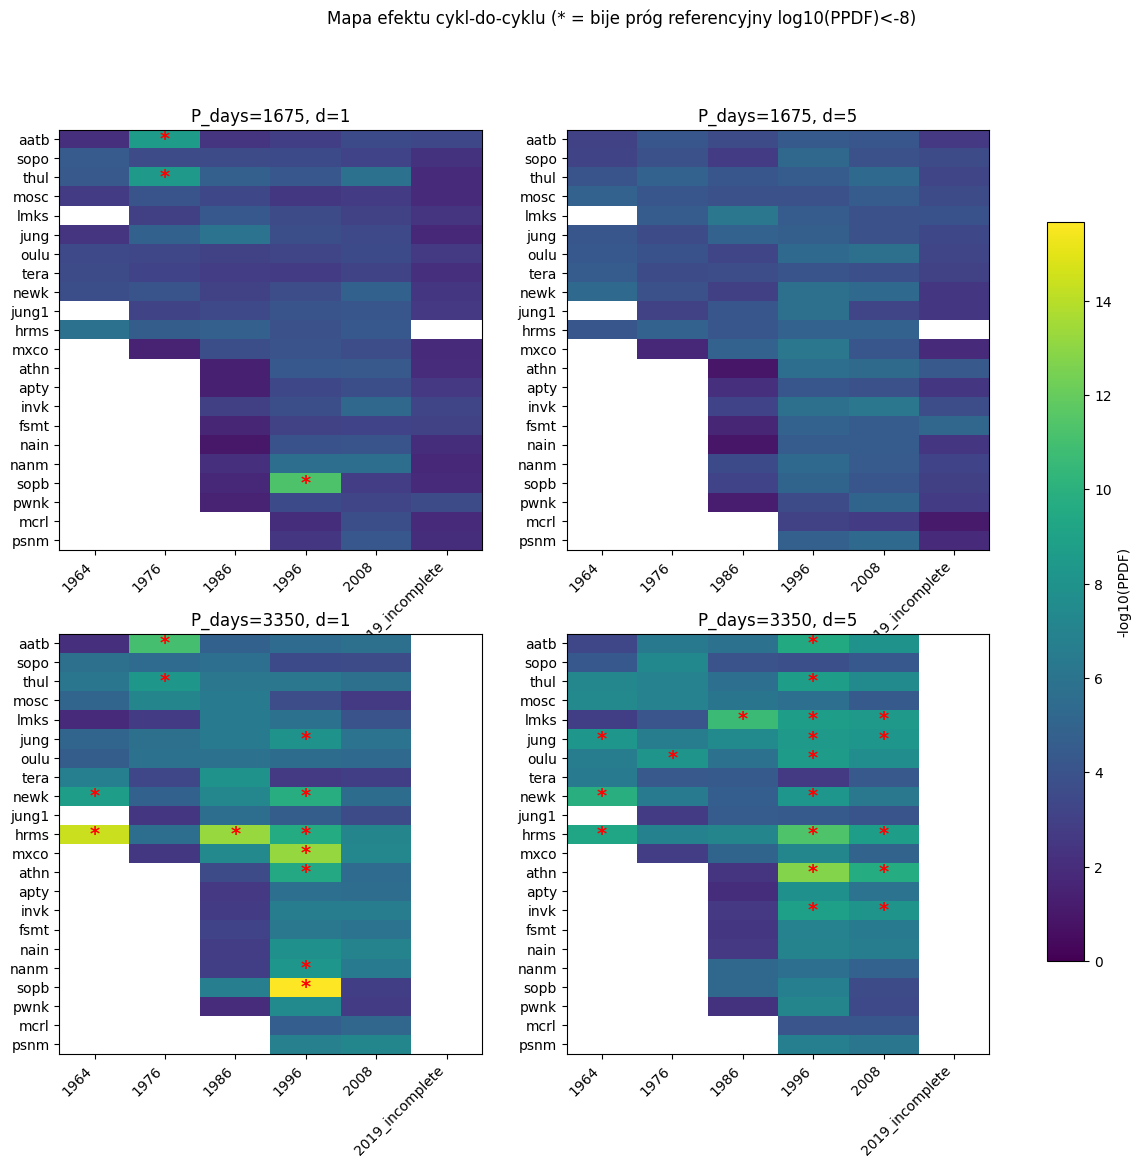

In [2]:
# MAPA CYKL-DO-CYKLU (to, o co prosil Homola): -log10(PPDF) ekstremum,
# stacja (wiersz) x cykl sloneczny (kolumna, chronologicznie), osobne panele
# dla kazdej kombinacji P_days x d (2x2 = 4 mapy). Gwiazdka = bije benchmark
# referencyjny. Puste (biale) pole = brak zadania (za mlodo dla stacji/cyklu
# lub P_days za dlugie na dany cykl). JEDEN wspolny colorbar (wspolne
# vmin/vmax) dla wszystkich 4 paneli - na prosbe Maćka (22.08), zeby kolory
# byly bezposrednio porownywalne miedzy P_days/d, nie tylko w obrebie
# jednego panelu.
if len(summary):
    cycle_order = summary.sort_values("cycle_year")["cycle"].unique()
    station_order = summary.groupby("station")["cycle_year"].nunique().sort_values(ascending=False).index

    vmax = (-summary["log10_PPDF"]).replace([np.inf, -np.inf], np.nan).max()

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    im = None
    for row_i, P_days in enumerate(sorted(summary["P_days"].unique())):
        for col_i, d in enumerate(sorted(summary["d"].unique())):
            ax = axes[row_i][col_i]
            sub = summary[(summary["P_days"] == P_days) & (summary["d"] == d)]
            pivot = sub.pivot(index="station", columns="cycle", values="log10_PPDF")
            pivot = pivot.reindex(index=station_order, columns=cycle_order)
            beats = sub.pivot(index="station", columns="cycle", values="beats_benchmark").reindex(
                index=station_order, columns=cycle_order)

            im = ax.imshow(-pivot.values, cmap="viridis", aspect="auto", vmin=0, vmax=vmax)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([c.replace("cycle_", "") for c in pivot.columns], rotation=45, ha="right")
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(f"P_days={P_days}, d={d}")
            for yi in range(len(pivot.index)):
                for xi in range(len(pivot.columns)):
                    # bool(NaN) w Pythonie to True - brakujaca (biala) komorka
                    # nie moze dostac gwiazdki, wiec pd.notna() jest wymagane
                    # PRZED rzutowaniem na bool (bug znaleziony przez Maćka
                    # 22.08 - cala kolumna "2019_incomplete" przy P=3350 miala
                    # gwiazdki mimo braku jakichkolwiek danych).
                    val = beats.values[yi, xi]
                    if pd.notna(val) and bool(val):
                        ax.text(xi, yi, "*", ha="center", va="center", color="red", fontsize=14, fontweight="bold")
    fig.colorbar(im, ax=axes, label="-log10(PPDF)", shrink=0.8)
    fig.suptitle("Mapa efektu cykl-do-cyklu (* = bije próg referencyjny log10(PPDF)<-8)")
    fig.savefig(f"{RESULTS_DIR}/cycle_scan_heatmap.png", dpi=120)
    plt.show()
else:
    print("Brak danych do narysowania mapy.")


In [3]:
# Odtworzenie granic cykli slonecznych - TA SAMA logika co
# 20260822c.ipynb komorka 2 (kopiowana, nie importowana - ten notebook ma
# byc samodzielny/bezpieczny do wielokrotnego odpalania, jak
# 20260820b.ipynb). Potrzebne tylko do wykresu FAZY nizej (poczatek kazdego
# cyklu, zeby policzyc "ile lat od poczatku cyklu" dla znalezionego t0).
from scipy.signal import find_peaks as _find_peaks
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess

sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
_smoothed = _lowess(sn["sunspot"].values, sn["rok_norm"].values, frac=0.01)[:, 1]
_min_idx, _ = _find_peaks(-_smoothed, distance=100, prominence=5)
cycle_min_dates = pd.to_datetime(sn["date"].values[_min_idx])
cycle_starts = {f"cycle_{d.year}": d for d in cycle_min_dates}
if len(cycle_min_dates):
    cycle_starts[f"cycle_{cycle_min_dates[-1].year}_incomplete"] = cycle_min_dates[-1]


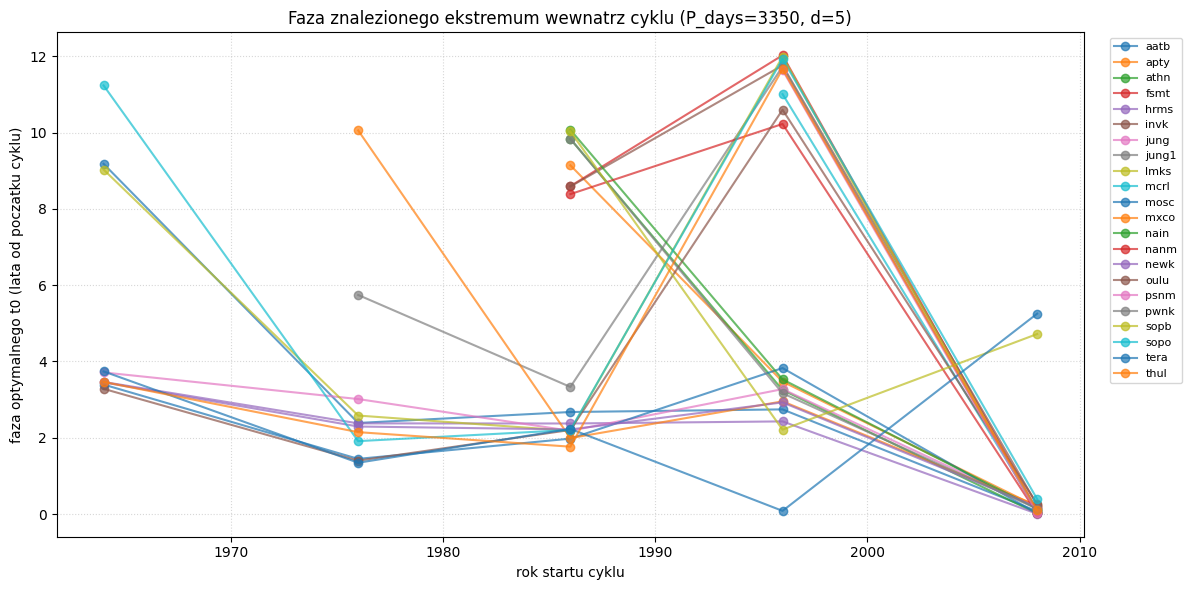

In [4]:
# Dodatkowy widok: FAZA optymalnego t0 wewnatrz cyklu (lata od poczatku
# cyklu do znalezionego ekstremum) per stacja, dla kombinacji P_days=3350,
# d=5 (ten sam "headline" wybor co w dotychczasowych skanach 19-20.08).
# Pyta: czy optymalne t0 klastruje sie w podobnej FAZIE cyklu w kazdej
# dekadzie (co byloby bardzo mocnym sygnalem), czy wygląda losowo?
if len(summary):
    sel = summary[(summary["P_days"] == 3350) & (summary["d"] == 5)].copy()
    sel["phase_years"] = sel.apply(
        lambda r: (r["t0_best"] - cycle_starts[r["cycle"]]).days / 365.25 if r["cycle"] in cycle_starts else np.nan,
        axis=1,
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    for station, g in sel.groupby("station"):
        g = g.sort_values("cycle_year")
        ax.plot(g["cycle_year"], g["phase_years"], "o-", label=station, alpha=0.7)
    ax.set_xlabel("rok startu cyklu")
    ax.set_ylabel("faza optymalnego t0 (lata od poczatku cyklu)")
    ax.set_title("Faza znalezionego ekstremum wewnatrz cyklu (P_days=3350, d=5)")
    ax.grid(ls=":", alpha=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/cycle_scan_phase_plot.png", dpi=120)
    plt.show()
else:
    print("Brak danych do narysowania wykresu fazy.")
